# 01 — Synthetic Transformer Telemetry Generation

This notebook generates 180 days of hourly sensor telemetry for a 25 MVA, 132/33 kV
power transformer, mimicking what an IoT gateway would stream from a real asset
in production.

**Why synthetic data?** Real transformer telemetry is proprietary and not publicly
available. The generator models the physical relationships between load, ambient
temperature, hotspot temperature, dissolved gas concentrations, and degradation
based on textbook physics (IEEE C57.91 thermal model + Arrhenius aging). This
gives us realistic data that the rest of the pipeline can be validated against.

**Sensor channels generated:**
- Electrical: load, voltages, currents
- Thermal: ambient, oil (top/bottom), winding hotspot
- DGA: H2, CH4, C2H2, C2H4, C2H6, CO, CO2
- Other: vibration, partial discharge, OLTC tap position

Two known faults are injected into the timeline so downstream models can be
validated end-to-end.


In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd

import matplotlib.pyplot as plt
from src.data_generator import generate_transformer_data
from src.visualization import setup_style, plot_load_and_temperature

setup_style()

## Generate 180 days of telemetry

In [2]:
df = generate_transformer_data(days=180, seed=42)
df.to_csv('../data/synthetic_transformer_telemetry.csv', index=False)
print(f"Shape: {df.shape}")
print(f"Date range: {df.timestamp.min()} to {df.timestamp.max()}")
df.head()

Shape: (4320, 21)
Date range: 2025-11-01 00:00:00 to 2026-04-29 23:00:00


,timestamp,load_pu,ambient_temp_c,oil_temp_top_c,oil_temp_bottom_c,winding_hotspot_c,voltage_hv_kv,voltage_lv_kv,current_hv_a,current_lv_a,...,ch4_ppm,c2h2_ppm,c2h4_ppm,c2h6_ppm,co_ppm,co2_ppm,vibration_rms_mm_s,partial_discharge_pc,oltc_position,fault_label
0,2025-11-01 00:00:00,0.3580,13.77,21.11,18.18,24.00,131.559,33.604,39.28,153.79,...,17.57,0.52,15.15,12.46,414.08,3504.77,0.995,11.6,9,0
1,2025-11-01 01:00:00,0.3148,13.38,19.36,16.97,22.43,131.691,32.751,34.50,138.74,...,19.67,1.02,13.30,12.31,406.14,3637.03,1.233,68.5,9,0
2,2025-11-01 02:00:00,0.3714,10.49,18.28,15.16,20.16,132.202,32.628,40.55,164.30,...,15.52,1.23,13.84,10.92,371.08,3428.74,1.302,34.6,9,0
3,2025-11-01 03:00:00,0.3856,10.81,19.08,15.77,20.14,130.983,33.446,42.49,166.41,...,15.98,0.93,16.34,12.61,367.85,3424.00,1.148,35.8,9,0
4,2025-11-01 04:00:00,0.3124,8.55,14.46,12.09,16.51,132.146,33.349,34.12,135.20,...,19.33,1.27,15.97,14.90,372.14,3434.33,1.331,96.7,9,0


## Fault label distribution

Most rows are normal operation. Two fault windows are injected:
- A thermal fault <300C around day 90
- A partial discharge event around day 140


In [3]:
df.fault_label.value_counts().sort_index()

fault_label
0    4148
1      43
4     129
Name: count, dtype: int64

## Visualize the first 30 days: load profile and hotspot temperature

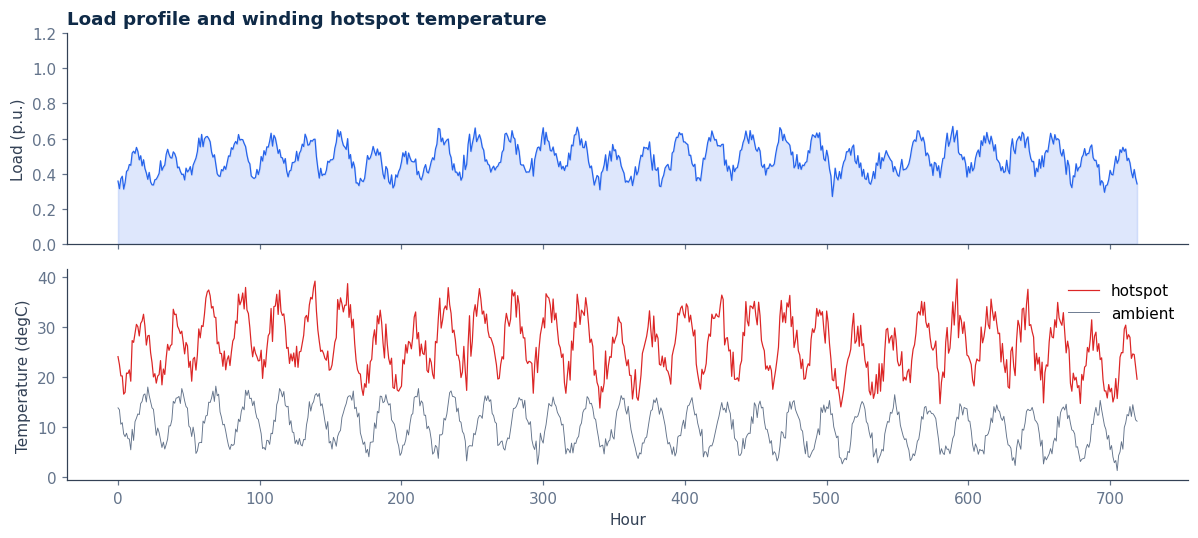

In [4]:
fig = plot_load_and_temperature(df, hours=24 * 30)
plt.show()

## Verify physical realism

A few sanity checks: the simulated hotspot should respond to load and ambient temperature in expected ways.


In [5]:
import numpy as np
print("Sensor statistics:")
print(df[["load_pu", "ambient_temp_c", "winding_hotspot_c",
          "oil_temp_top_c", "h2_ppm", "vibration_rms_mm_s"]].describe().round(2))

Sensor statistics:
       load_pu  ambient_temp_c  winding_hotspot_c  oil_temp_top_c   h2_ppm  \
count  4320.00         4320.00            4320.00         4320.00  4320.00   
mean      0.54           14.09              33.69           28.49    30.96   
std       0.09            7.11               9.56            8.49     9.16   
min       0.27            0.12              13.00           11.29    19.53   
25%       0.47            8.55              26.19           21.85    28.26   
50%       0.54           13.07              32.86           27.38    30.28   
75%       0.61           19.02              40.53           34.63    32.20   
max       0.80           33.82              62.70           51.75   179.39   

       vibration_rms_mm_s  
count             4320.00  
mean                 1.47  
std                  0.15  
min                  0.93  
25%                  1.37  
50%                  1.47  
75%                  1.57  
max                  2.00  


In [6]:
# Correlation between load and hotspot - should be strongly positive
corr = df["load_pu"].corr(df["winding_hotspot_c"])
print(f"Correlation(load, hotspot) = {corr:.3f}  (expect > 0.8)")

Correlation(load, hotspot) = 0.669  (expect > 0.8)


## Next step

Notebook **02_physics_model** uses this telemetry as input to the physics-based
thermal and aging models, and computes the *residual* between physics prediction
and the simulated measurement. That residual is the key feature the ML layer uses
in notebook 03.
